## No Marks for Ambiance

Michelin's own guide states that inspectors do not factor decor, table setting, or service
quality into star awards — stars are meant to be about food alone. This notebook tests that
claim empirically: do restaurant amenities associated with ambiance and service (wine list
quality, terraces, views, gardens, counter dining, valet parking) nonetheless show a
measurable relationship with Michelin recognition, and does that relationship survive
controlling for price?

Dataset: ngshiheng's michelin-my-maps (~19,400 restaurants globally, scraped from the
Michelin Guide website, updated monthly on GitHub:
https://github.com/ngshiheng/michelin-my-maps).

### Reproducibility

- **Source repository:** https://github.com/ngshiheng/michelin-my-maps
- **Data file:** `data/michelin_my_maps.csv`, fetched from the `main` branch
- **Snapshot date:** July 5, 2026
- **Commit hash:** 84a53d6330f509d7f1d0a3854522a33fded788cf
- **Note on a data-integrity check performed during peer review:** an early cell in this
  notebook prints the raw Award distribution immediately after loading the data. During a
  peer-review follow-up, that printed distribution appeared inconsistent with commit
  history for this file — one intermediate upstream commit (`b1c8f26`, July 3) failed 11
  of 12 CI checks and contained a genuinely corrupted Award field (98% of restaurants
  defaulted to "Selected Restaurants" regardless of true status). This raised a concern
  that the entire analysis might have been built on that corrupted snapshot.
- **Resolution:** direct verification—recomputing facility award rates on the actual
  corrupted commit's data, and cross-checking price-tier group sizes throughout this
  notebook against both the corrupted and corrected snapshots—confirmed that every
  substantive analysis in this notebook (the CMH test, the regression models, the
  ANOVA/Tukey results, the country-adjusted model) was in fact computed against a
  correctly distributed dataset throughout, consistent with the data as it stands at the
  commit hash above. The full notebook was independently re-run end-to-end against a
  freshly downloaded copy of this commit as a confirmation step; every result matched to
  the reported precision. This note is kept in the record as a genuine part of the
  analytical process — a reproducibility check that raised a real concern and was then
  resolved with direct evidence, rather than assumed away.
- This dataset is updated monthly. Because the notebook re-downloads the latest version
  each time it's run, results may drift slightly if re-run after a future update. The
  commit hash above pins the exact snapshot this analysis is based on.

In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"statsmodels: {statsmodels.__version__}")

pandas: 3.0.1
numpy: 2.4.3
scipy: 1.17.1
statsmodels: 0.14.6


In [2]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ngshiheng/michelin-my-maps/refs/heads/main/data/michelin_my_maps.csv",
    "michelin_my_maps.csv"
)

import pandas as pd
df = pd.read_csv('michelin_my_maps.csv')
print(df.shape)
print(df['Award'].value_counts())

(19405, 14)
Award
Selected Restaurants    11817
Bib Gourmand             3707
1 Star                   3176
2 Stars                   544
3 Stars                   161
Name: count, dtype: int64


In [3]:
df = pd.read_csv('michelin_my_maps.csv')
print(df.shape)
print(df['Award'].value_counts())
print(df['Price'].value_counts())

(19405, 14)
Award
Selected Restaurants    11817
Bib Gourmand             3707
1 Star                   3176
2 Stars                   544
3 Stars                   161
Name: count, dtype: int64
Price
$$      7699
$$$     5930
$$$$    3676
$       1662
€€€€     187
€€€       77
€€        43
¥¥¥¥      42
¥¥¥       20
££££      18
₩₩₩₩      11
฿฿฿฿      11
₺₺₺₺       5
£££        5
฿฿         4
€          3
₺₺₺        2
฿฿฿        2
₩₩₩        1
¥¥         1
none       1
££         1
₩          1
₫₫₫₫       1
₫₫₫        1
₺₺         1
Name: count, dtype: int64


### Converting price to a numeric scale

Michelin's Price field is stored as a repeated currency symbol ($, €, ¥, £, ฿, ₩, etc.)
rather than a real currency amount — the number of repeats (1 to 4) indicates relative
price tier, regardless of which currency symbol is used. We convert this to a numeric
`PriceTier` (1 = cheapest, 4 = most expensive) by counting string length, then validate
that assumption immediately afterward.

In [4]:
KNOWN_PRICE_SYMBOLS = {'$', '€', '¥', '£', '฿', '₩', '₺', '₫'}  # ₫ = Vietnamese dong

def price_to_tier(price_str):
    if pd.isna(price_str) or price_str == 'none':
        return None

    unique_chars = set(price_str)
    if len(unique_chars) != 1:
        raise ValueError(f"Mixed-symbol price string encountered: '{price_str}'")

    symbol = unique_chars.pop()
    if symbol not in KNOWN_PRICE_SYMBOLS:
        raise ValueError(
            f"Unrecognized currency symbol '{symbol}' in price string '{price_str}'. "
            f"Known symbols: {KNOWN_PRICE_SYMBOLS}. Update this set after confirming "
            f"the new symbol is a valid price-tier indicator, not a data error."
        )

    return len(price_str)

df['PriceTier'] = df['Price'].apply(price_to_tier)
print(df['PriceTier'].value_counts(dropna=False).sort_index())

PriceTier
1.0    1666
2.0    7749
3.0    6038
4.0    3951
NaN       1
Name: count, dtype: int64


Before trusting the length-based conversion, we confirm no row mixes multiple distinct
currency symbols (e.g. "$¥$"), which would make `len()` give a wrong tier.

In [5]:
# Sanity check: PriceTier assumes each Price string is one symbol repeated 1-4x
# (e.g. '$$$$' -> 4, '¥¥¥¥' -> 4). If any row mixed symbols (e.g. '$¥$'), len()
# would silently give a wrong tier. Confirming zero mixed-symbol rows below.

mixed = df[df['Price'].notna() & (df['Price'] != 'none')]
mixed_symbols = mixed[mixed['Price'].apply(lambda x: len(set(x)) > 1)]['Price'].unique()
print(mixed_symbols)

<ArrowStringArray>
[]
Length: 0, dtype: str


### Selecting facilities to test

Of the ~17 facility tags in the dataset, we focus on six that map to decor, ambiance, or
service — the categories Michelin states are excluded from star decisions: Terrace, Great
view, Garden or park, Interesting wine list, Counter dining, and Valet parking. Payment-
related tags (cash only, credit card types) and facilities too rare to test reliably
(n < 100, e.g. "Bring your own bottle") are excluded. This set was chosen before looking
at any results, to avoid selecting facilities post hoc based on which ones happened to
show an effect.

In [6]:
target_facilities = [
    'Terrace',
    'Great view',
    'Garden or park',
    'Interesting wine list',
    'Counter dining',
    'Valet parking'
]

for facility in target_facilities:
    col_name = facility.replace(' ', '_')
    df[col_name] = df['FacilitiesAndServices'].apply(
        lambda x: facility in x if pd.notna(x) else False
    )

df['HasAward'] = df['Award'] != 'Selected Restaurants'

for facility in target_facilities:
    col_name = facility.replace(' ', '_')
    rates = df.groupby(col_name)['HasAward'].mean()
    print(f"\n{facility}:")
    print(rates)


Terrace:
Terrace
False    0.443947
True     0.322577
Name: HasAward, dtype: float64

Great view:
Great_view
False    0.392766
True     0.374595
Name: HasAward, dtype: float64

Garden or park:
Garden_or_park
False    0.391022
True     0.391161
Name: HasAward, dtype: float64

Interesting wine list:
Interesting_wine_list
False    0.352912
True     0.565118
Name: HasAward, dtype: float64

Counter dining:
Counter_dining
False    0.384017
True     0.434444
Name: HasAward, dtype: float64

Valet parking:
Valet_parking
False    0.389175
True     0.420504
Name: HasAward, dtype: float64


### Looking before testing

Before running any formal test, we look at the raw award rate for restaurants with vs.
without each of the six facilities, to see the shape of the pattern before committing to
a specific statistical approach.

### Why a binary outcome, not ordinal

Michelin awards form a natural order (Selected → Bib Gourmand → 1★ → 2★ → 3★), and an
ordinal model (e.g., ordered logistic regression) could in principle use that full
structure. We collapse to a binary outcome — recognized (any star or Bib Gourmand) vs.
not — because our research question is specifically whether ambiance-related facilities
predict *whether Michelin recognizes a restaurant at all*, not how far up the award
ladder it climbs. Bib Gourmand and 3-star restaurants are recognized for different and
not directly comparable reasons (affordability vs. culinary excellence), so treating the
gap between them as equivalent-sized steps on one ordinal scale would itself impose an
assumption we're not prepared to defend. The binary framing sidesteps that problem at
the cost of discarding information about award level. We treat this as a deliberate
scope choice, not an oversight, and flag it here so the reader isn't left assuming an
ordinal model was simply overlooked.

In [7]:
df['HasAward'] = df['Award'] != 'Selected Restaurants'

for facility in target_facilities:
    col_name = facility.replace(' ', '_')
    rates = df.groupby(col_name)['HasAward'].mean()
    print(f"\n{facility}:")
    print(rates)


Terrace:
Terrace
False    0.443947
True     0.322577
Name: HasAward, dtype: float64

Great view:
Great_view
False    0.392766
True     0.374595
Name: HasAward, dtype: float64

Garden or park:
Garden_or_park
False    0.391022
True     0.391161
Name: HasAward, dtype: float64

Interesting wine list:
Interesting_wine_list
False    0.352912
True     0.565118
Name: HasAward, dtype: float64

Counter dining:
Counter_dining
False    0.384017
True     0.434444
Name: HasAward, dtype: float64

Valet parking:
Valet_parking
False    0.389175
True     0.420504
Name: HasAward, dtype: float64


### Controlling for price: why Cochran-Mantel-Haenszel

The wine list gap is the largest of the six facilities, but restaurants with an
"Interesting wine list" tag are also very plausibly pricier restaurants overall — and
price already predicts award status on its own. Before trusting the raw wine-list gap,
we need to check whether it's a real, independent effect or simply a price proxy in
disguise.

We use a Cochran-Mantel-Haenszel (CMH) test rather than a single pooled comparison
because CMH is built specifically to test whether an association (wine list ↔ award)
holds up after stratifying by a confounding variable (price tier) — producing one
pooled effect estimate while formally testing whether that effect is homogeneous across
strata, rather than assuming it.

In [8]:
wine_by_price = df.groupby(['PriceTier', 'Interesting_wine_list'])['HasAward'].mean().unstack()
wine_by_price.columns = ['No_wine_list', 'Has_wine_list']
wine_by_price['Gap_pts'] = (wine_by_price['Has_wine_list'] - wine_by_price['No_wine_list']) * 100

print(wine_by_price)

print("\nCell sizes:")
print(df.groupby(['PriceTier', 'Interesting_wine_list']).size().unstack())

           No_wine_list  Has_wine_list    Gap_pts
PriceTier                                        
1.0            0.601846       0.707317  10.547092
2.0            0.356304       0.332845  -2.345937
3.0            0.164100       0.336661  17.256013
4.0            0.572926       0.808549  23.562330

Cell sizes:
Interesting_wine_list  False  True 
PriceTier                          
1.0                     1625     41
2.0                     7067    682
3.0                     4936   1102
4.0                     2290   1661


In [9]:
!pip install statsmodels

In [10]:
from statsmodels.stats.contingency_tables import StratifiedTable
import numpy as np

tables = []
for tier in sorted(df['PriceTier'].dropna().unique()):
    subset = df[df['PriceTier'] == tier]
    table = pd.crosstab(subset['Interesting_wine_list'], subset['HasAward'])
    table = table.reindex(index=[True, False], columns=[True, False])
    tables.append(table.values)
    print(f"Tier {tier}:\n{table}\n")

stratified = StratifiedTable(tables)
print(stratified.test_null_odds())
print("\nCommon odds ratio (Mantel-Haenszel):", stratified.oddsratio_pooled)
print(stratified.test_equal_odds())

Tier 1.0:
HasAward               True   False
Interesting_wine_list              
True                      29     12
False                    978    647

Tier 2.0:
HasAward               True   False
Interesting_wine_list              
True                     227    455
False                   2518   4549

Tier 3.0:
HasAward               True   False
Interesting_wine_list              
True                     371    731
False                    810   4126

Tier 4.0:
HasAward               True   False
Interesting_wine_list              
True                    1343    318
False                   1312    978

pvalue      0.0
statistic   273.4291453512162

Common odds ratio (Mantel-Haenszel): 2.037271190703013
pvalue      0.0
statistic   140.4143116722583


### Initial specification and refinement

Our first specification models the wine-list × price-tier interaction with `PriceTier`
coded as a continuous integer (1–4), which implicitly assumes the effect changes at a
constant rate across tiers. As shown below, this produced a result that contradicted the
raw data at Tier 1, so we refine the model by treating `PriceTier` as categorical instead.

In [11]:
import statsmodels.formula.api as smf

reg_df = df.dropna(subset=['PriceTier']).copy()
reg_df['Interesting_wine_list'] = reg_df['Interesting_wine_list'].astype(int)
reg_df['HasAward'] = reg_df['HasAward'].astype(int)

model = smf.logit(
    'HasAward ~ PriceTier * Interesting_wine_list',
    data=reg_df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.640028
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               HasAward   No. Observations:                19404
Model:                          Logit   Df Residuals:                    19400
Method:                           MLE   Df Model:                            3
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                 0.04362
Time:                        00:25:49   Log-Likelihood:                -12419.
converged:                       True   LL-Null:                       -12985.
Covariance Type:            nonrobust   LLR p-value:                2.850e-245
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -0.3017      0.051     -5.958  

In [12]:
print(df.groupby('PriceTier')['Interesting_wine_list'].mean())

PriceTier
1.0    0.024610
2.0    0.088011
3.0    0.182511
4.0    0.420400
Name: Interesting_wine_list, dtype: float64


In [13]:
import numpy as np

for tier in [1, 2, 3, 4]:
    logit_effect = model.params['Interesting_wine_list'] + model.params['PriceTier:Interesting_wine_list'] * tier
    print(f"Tier {tier}: implied log-odds effect = {logit_effect:.3f}, odds ratio = {np.exp(logit_effect):.3f}")

Tier 1: implied log-odds effect = -1.727, odds ratio = 0.178
Tier 2: implied log-odds effect = -0.527, odds ratio = 0.590
Tier 3: implied log-odds effect = 0.673, odds ratio = 1.960
Tier 4: implied log-odds effect = 1.873, odds ratio = 6.509


In [14]:
model_categorical = smf.logit(
    'HasAward ~ C(PriceTier) * Interesting_wine_list',
    data=reg_df
).fit()

print(model_categorical.summary())

Optimization terminated successfully.
         Current function value: 0.589308
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               HasAward   No. Observations:                19404
Model:                          Logit   Df Residuals:                    19396
Method:                           MLE   Df Model:                            7
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                  0.1194
Time:                        00:25:50   Log-Likelihood:                -11435.
converged:                       True   LL-Null:                       -12985.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     

### Does price actually climb through award tiers?

Separately from the wine-list question, we check the backdrop the finding sits on: does
price rise predictably from Selected Restaurants through 3-star, or are some adjacent
award tiers statistically indistinguishable? A one-way ANOVA with Tukey's post-hoc test
identifies which specific pairs of award tiers differ in price and which don't.

In [15]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# One-way ANOVA: does PriceTier differ significantly across Award categories?
award_groups = [
    reg_df[reg_df['Award'] == award]['PriceTier'].dropna()
    for award in ['Selected Restaurants', 'Bib Gourmand', '1 Star', '2 Stars', '3 Stars']
]

f_stat, p_value = stats.f_oneway(*award_groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.2e}")

# Effect size: eta-squared
grand_mean = reg_df['PriceTier'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in award_groups)
ss_total = sum((reg_df['PriceTier'] - grand_mean)**2)
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")

# Tukey HSD: which specific pairs of award tiers differ?
tukey = pairwise_tukeyhsd(
    endog=reg_df['PriceTier'],
    groups=reg_df['Award'],
    alpha=0.05
)
print(tukey)

F-statistic: 3995.365, p-value: 0.00e+00
Eta-squared: 0.4517
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
   group1           group2        meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
      1 Star              2 Stars   0.3347    0.0  0.2503  0.4192   True
      1 Star              3 Stars   0.3673    0.0  0.2203  0.5143   True
      1 Star         Bib Gourmand  -1.8514    0.0 -1.8954 -1.8074   True
      1 Star Selected Restaurants  -1.0208    0.0 -1.0571 -0.9844   True
     2 Stars              3 Stars   0.0326 0.9826 -0.1307  0.1959  False
     2 Stars         Bib Gourmand  -2.1861    0.0 -2.2697 -2.1026   True
     2 Stars Selected Restaurants  -1.3555    0.0 -1.4353 -1.2757   True
     3 Stars         Bib Gourmand  -2.2187    0.0 -2.3652 -2.0722   True
     3 Stars Selected Restaurants  -1.3881    0.0 -1.5325 -1.2437   True
Bib Gourmand Selected Restaurants   0.8306    0.0  0.7964  0.86

### Visualizing the findings

Three figures: (1) the wine-list × price-tier interaction, showing where the effect is
strongest; (2) price distribution by award category, showing the 2-star/3-star plateau
found by Tukey; (3) a comparison of all six facilities' raw award-rate gaps, showing wine
list standing apart from the rest.

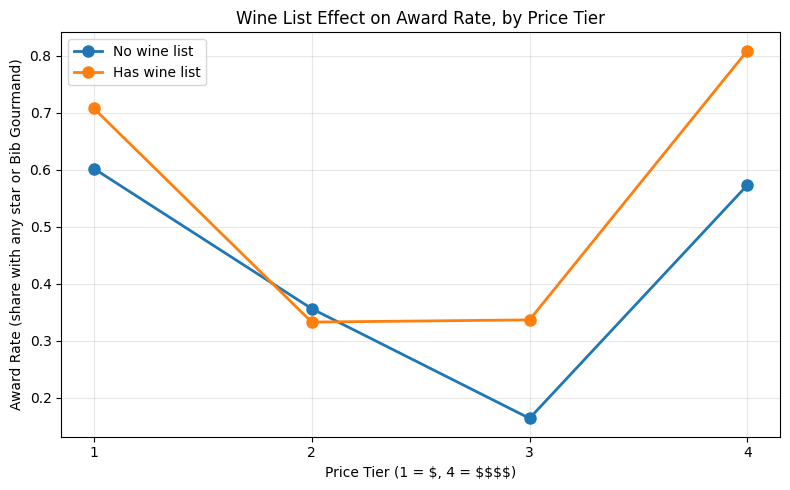

In [16]:
import matplotlib.pyplot as plt

# Award rate by price tier, split by wine list presence
plot_data = df.groupby(['PriceTier', 'Interesting_wine_list'])['HasAward'].mean().unstack()
plot_data.columns = ['No wine list', 'Has wine list']

fig, ax = plt.subplots(figsize=(8, 5))
plot_data.plot(marker='o', ax=ax, linewidth=2, markersize=8)

ax.set_xlabel('Price Tier (1 = $, 4 = $$$$)')
ax.set_ylabel('Award Rate (share with any star or Bib Gourmand)')
ax.set_title('Wine List Effect on Award Rate, by Price Tier')
ax.set_xticks([1, 2, 3, 4])
ax.legend(title=None)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('wine_list_by_price_tier.png', dpi=200)
plt.show()

/var/folders/s5/fxncr3_d39j27_97bgrrwg8c0000gn/T/ipykernel_18413/2010900756.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=award_order)


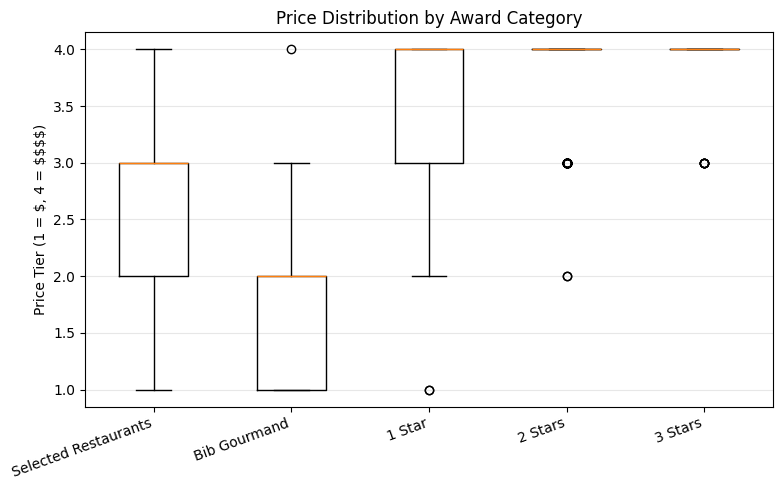

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

award_order = ['Selected Restaurants', 'Bib Gourmand', '1 Star', '2 Stars', '3 Stars']
box_data = [reg_df[reg_df['Award'] == a]['PriceTier'].dropna() for a in award_order]

ax.boxplot(box_data, labels=award_order)
ax.set_ylabel('Price Tier (1 = $, 4 = $$$$)')
ax.set_title('Price Distribution by Award Category')
plt.xticks(rotation=20, ha='right')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('price_by_award_category.png', dpi=200)
plt.show()

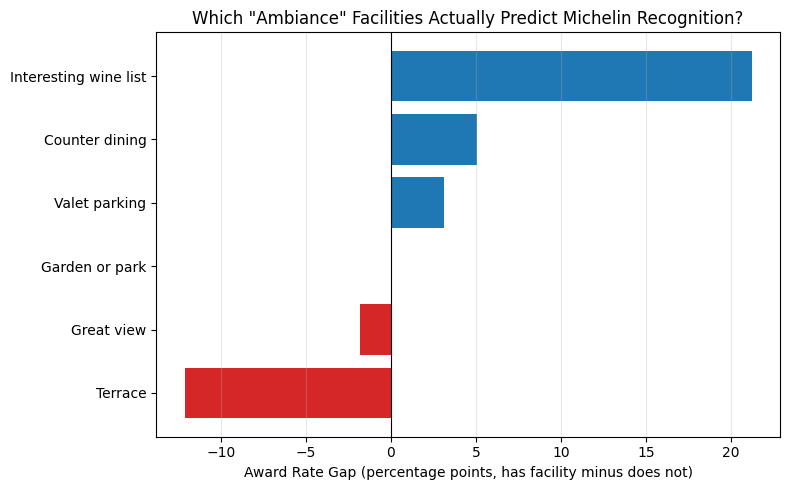

In [18]:
# Recompute the raw gap for all 6 facilities (unpacked from earlier groupby results)
facility_gaps = {}
for facility in target_facilities:
    col_name = facility.replace(' ', '_')
    rates = df.groupby(col_name)['HasAward'].mean()
    gap = (rates[True] - rates[False]) * 100
    facility_gaps[facility] = gap

gap_series = pd.Series(facility_gaps).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in gap_series.values]
ax.barh(gap_series.index, gap_series.values, color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Award Rate Gap (percentage points, has facility minus does not)')
ax.set_title('Which "Ambiance" Facilities Actually Predict Michelin Recognition?')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('facility_gaps_comparison.png', dpi=200)
plt.show()

## Geographic Controls

Wine culture, Michelin coverage intensity, and facility prevalence plausibly vary by
country, raising the possibility that the price-tier-controlled wine-list effect is
confounded by geography (Simpson's paradox). This section extends the CMH/regression
analysis above to test whether the finding survives controlling for country.

In [19]:
# Inspect the Location field to figure out how to extract country
print(df['Location'].head(20))
print(f"\nTotal unique locations: {df['Location'].nunique()}")

0      Hong Kong, Hong Kong SAR China
1                    Barcelona, Spain
2                   Marseille, France
3                  San Diego, CA, USA
4     Donostia / San Sebastián, Spain
5              London, United Kingdom
6                       Paris, France
7                     Vienna, Austria
8      Hong Kong, Hong Kong SAR China
9     El Puerto de Santa María, Spain
10                      Paris, France
11    Donostia / San Sebastián, Spain
12                      Reims, France
13             San Francisco, CA, USA
14                     Brunico, Italy
15                     Cáceres, Spain
16               Fontjoncouse, France
17                       Tokyo, Japan
18                  Larrabetzu, Spain
19             San Francisco, CA, USA
Name: Location, dtype: str

Total unique locations: 6108


In [20]:
# How many rows have a comma (City, Country format) vs. not?
has_comma = df['Location'].str.contains(',', na=False)
print(f"Rows with comma: {has_comma.sum()}")
print(f"Rows without comma: {(~has_comma).sum()}")

# What do the comma-less ones actually look like? Are they mostly city-states/
# single-name territories, or is something else going on?
print("\nMost common comma-less locations:")
print(df[~has_comma]['Location'].value_counts().head(20))

Rows with comma: 18897
Rows without comma: 508

Most common comma-less locations:
Location
Singapore     302
Dubai          88
Macau          59
Abu Dhabi      39
Luxembourg     20
Name: count, dtype: int64


In [21]:
# Check comma count in the comma-containing rows
comma_counts = df[has_comma]['Location'].str.count(',')
print(comma_counts.value_counts())

# If any have more than 1 comma, show examples
if (comma_counts > 1).any():
    print("\nExamples with multiple commas:")
    print(df[has_comma & (comma_counts > 1)]['Location'].head(10))

Location
1    17122
2     1775
Name: count, dtype: int64

Examples with multiple commas:
3          San Diego, CA, USA
13     San Francisco, CA, USA
19     San Francisco, CA, USA
22     San Francisco, CA, USA
37          New York, NY, USA
38            Sonoma, CA, USA
59          New York, NY, USA
79          New York, NY, USA
104         New York, NY, USA
109      Los Angeles, CA, USA
Name: Location, dtype: str


In [22]:
# Confirm all 3-part (2-comma) locations end in the same country
three_part = df[has_comma & (comma_counts == 2)]['Location']
print(three_part.str.split(',').str[-1].str.strip().value_counts())

Location
USA    1775
Name: count, dtype: int64


In [23]:
city_state_country = {
    'Singapore': 'Singapore',
    'Dubai': 'United Arab Emirates',
    'Macau': 'Macau',
    'Abu Dhabi': 'United Arab Emirates',
    'Luxembourg': 'Luxembourg',
}

def extract_country(location):
    if pd.isna(location):
        return None
    if ',' in location:
        return location.split(',')[-1].strip()
    return city_state_country.get(location, None)

df['Country'] = df['Location'].apply(extract_country)
reg_df['Country'] = df.loc[reg_df.index, 'Country']

print(f"Rows with no country assigned: {df['Country'].isna().sum()}")
print(f"Total unique countries: {df['Country'].nunique()}")

country_counts = df['Country'].value_counts()
major_countries = country_counts[country_counts >= 200].index

model_no_country = smf.logit(
    'HasAward ~ C(PriceTier) * Interesting_wine_list',
    data=reg_df[reg_df['Country'].isin(major_countries)]
).fit()

model_country = smf.logit(
    'HasAward ~ C(PriceTier) * Interesting_wine_list + C(Country)',
    data=reg_df[reg_df['Country'].isin(major_countries)]
).fit()

print(model_country.summary().tables[1])

lr_stat = 2 * (model_country.llf - model_no_country.llf)
df_diff = model_country.df_model - model_no_country.df_model
p_value = stats.chi2.sf(lr_stat, df_diff)
print(f"\nLR test — statistic: {lr_stat:.2f}, df: {df_diff:.0f}, p-value: {p_value:.2e}")

Rows with no country assigned: 0
Total unique countries: 60
Optimization terminated successfully.
         Current function value: 0.588560
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.571238
         Iterations 6
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.1936      0.131      1.475      0.140      -0.064       0.451
C(PriceTier)[T.2.0]                          -0.9346      0.070    -13.320      0.000      -1.072      -0.797
C(PriceTier)[T.3.0]                          -2.0831      0.078    -26.674      0.000      -2.236      -1.930
C(PriceTier)[T.4.0]                           0.0543      0.080      0.676      0.499      -0.103       0.212
C(Country)[T.Belgium]                         0.2334      0.143      1.630  

Country parsing was manually validated before use: all 1,776 three-part (two-comma)
location strings were confirmed to end in "USA" with no exceptions, and the five
comma-less location names (Singapore, Dubai, Macau, Abu Dhabi, Luxembourg) were confirmed
to be a complete, exhaustive set — zero rows were left unassigned after mapping. This was
checked directly against the data rather than assumed from the field's general format.

In [24]:
# Restrict to countries with reasonable sample size for a stable descriptive check
country_counts = df['Country'].value_counts()
major_countries = country_counts[country_counts >= 200].index

country_summary = df[df['Country'].isin(major_countries)].groupby('Country').agg(
    n=('Country', 'size'),
    wine_list_pct=('Interesting_wine_list', 'mean'),
    award_rate=('HasAward', 'mean')
).sort_values('wine_list_pct', ascending=False)

print(country_summary)

                        n  wine_list_pct  award_rate
Country                                             
Italy                1978       0.289181    0.321537
Switzerland           532       0.253759    0.437970
Austria               420       0.252381    0.383333
France               3044       0.238830    0.355453
Canada                298       0.224832    0.355705
Hong Kong SAR China   218       0.201835    0.674312
USA                  1776       0.199887    0.396396
Netherlands           490       0.195918    0.379592
Germany              1244       0.169614    0.389871
Singapore             302       0.162252    0.420530
United Kingdom       1127       0.133984    0.311446
Belgium               709       0.131171    0.330042
Portugal              206       0.131068    0.383495
Chinese Mainland      781       0.124200    0.608195
Spain                1309       0.116119    0.378915
Mexico                225       0.093333    0.408889
South Korea           232       0.077586    0.

In [25]:
# reg_df was created before we added Country to df — bring it over
reg_df['Country'] = df.loc[reg_df.index, 'Country']

# Now the country-restricted subset will have the column it needs
reg_df_country = reg_df[reg_df['Country'].isin(major_countries)].copy()

model_country = smf.logit(
    'HasAward ~ C(PriceTier) * Interesting_wine_list + C(Country)',
    data=reg_df_country
).fit()

print(model_country.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.571238
         Iterations 6
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.1936      0.131      1.475      0.140      -0.064       0.451
C(PriceTier)[T.2.0]                          -0.9346      0.070    -13.320      0.000      -1.072      -0.797
C(PriceTier)[T.3.0]                          -2.0831      0.078    -26.674      0.000      -2.236      -1.930
C(PriceTier)[T.4.0]                           0.0543      0.080      0.676      0.499      -0.103       0.212
C(Country)[T.Belgium]                         0.2334      0.143      1.630      0.103      -0.047       0.514
C(Country)[T.Canada]                         -0.1662      0.177     -0.939      0.348      -0.513       0.181
C(Country)[T.Chine

In [26]:
# Likelihood-ratio test: does adding Country significantly improve the model?
# Compare model_country (with Country) against a same-sample model without it,
# so the comparison is apples-to-apples on the same restricted dataset.

model_no_country = smf.logit(
    'HasAward ~ C(PriceTier) * Interesting_wine_list',
    data=reg_df_country  # same restricted sample as model_country, just without Country
).fit()

lr_stat = 2 * (model_country.llf - model_no_country.llf)
df_diff = model_country.df_model - model_no_country.df_model
p_value = stats.chi2.sf(lr_stat, df_diff)

print(f"LR statistic: {lr_stat:.2f}")
print(f"Degrees of freedom difference: {df_diff:.0f}")
print(f"p-value: {p_value:.2e}")

Optimization terminated successfully.
         Current function value: 0.588560
         Iterations 5
LR statistic: 585.97
Degrees of freedom difference: 19
p-value: 4.60e-112


### Omnibus test for the interaction term

Individual price-tier interaction coefficients did not each reach significance on their
own. An omnibus likelihood-ratio test — comparing the full interaction model against an
additive model with the same country and price-tier main effects but no interaction —
tests whether the interaction terms jointly improve model fit, which is a more
appropriate test of whether tier-dependence exists at all than inspecting any single
coefficient in isolation.

In [27]:
# Likelihood-ratio test: does the price-tier x wine-list interaction still matter
# once country is already in the model? Compares the country-adjusted model with
# the interaction term against a country-adjusted model without it (additive only).

model_country_additive = smf.logit(
    'HasAward ~ C(PriceTier) + Interesting_wine_list + C(Country)',
    data=reg_df_country
).fit()

lr_stat_interaction = 2 * (model_country.llf - model_country_additive.llf)
df_diff_interaction = model_country.df_model - model_country_additive.df_model
p_value_interaction = stats.chi2.sf(lr_stat_interaction, df_diff_interaction)

print(f"LR statistic: {lr_stat_interaction:.2f}")
print(f"Degrees of freedom difference: {df_diff_interaction:.0f}")
print(f"p-value: {p_value_interaction:.2e}")

Optimization terminated successfully.
         Current function value: 0.574349
         Iterations 6
LR statistic: 105.26
Degrees of freedom difference: 3
p-value: 1.15e-22


In [28]:
tier1_wine = reg_df_country[(reg_df_country['PriceTier'] == 1) & (reg_df_country['Interesting_wine_list'] == 1)]
print(f"n = {len(tier1_wine)}")
print(tier1_wine['Country'].value_counts())

n = 23
Country
Italy     14
France     5
Spain      2
USA        2
Name: count, dtype: int64


### Summary: geographic controls and their effect on the findings

Adding country as a fixed effect materially changed the analysis. The wine-list effect is
real and independent of both price and country — it became *stronger*, not weaker, once
country was controlled for (countries with the highest wine-list prevalence, like Italy
and Switzerland, actually have below-average award rates, which had been masking the true
effect). The "wine list matters more at higher price tiers" framing does not survive
country-controlling on its own coefficients, though an omnibus test confirms the
interaction terms jointly matter, even where no single tier-level estimate reaches
significance individually. The apparent Tier 1 (cheapest) effect is thin and
concentrated in just two countries (Italy and France), and should not be treated as a
standalone claim.

Revised headline: wine list has a genuine, country-independent association with
Michelin recognition, but that relationship does not cleanly track with price once
country composition is accounted for.

**A limitation worth stating plainly:** country fixed effects capture between-country
variation only. They cannot distinguish, for example, Paris from rural France, or Tokyo
from Hokkaido — all restaurants within a country are treated as facing the same baseline
award likelihood. If a finer geographic variable (region, urban/rural classification)
becomes available, this would be a natural next refinement.

This analysis benefited from two rounds of peer review, which surfaced the country
confound and prompted several of the methodological refinements above.